### **Importing Libraries**

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac

### **Loading Sample Data**

In [103]:
# Set log-level to reduce verbosity
mne.set_log_level('WARNING')

# Load sample dataset
data_path = mne.datasets.sample.data_path()
raw_fname = os.path.join(data_path, 'MEG/sample/sample_audvis_filt-0-40_raw.fif')
raw = mne.io.read_raw_fif(raw_fname, preload=True)

# High-pass filter the data
raw.filter(l_freq=0.5, h_freq=40, verbose=False)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MiB, data loaded>

### **Extracting Events and Creating Epochs**

In [9]:
# Extract events and create epochs
events = mne.find_events(raw, stim_channel='STI 014', verbose=True)
event_id = {'aud_l': 1, 'aud_r': 2}

# Epochs parameters
tmin = -0.1  # Start of epoch in seconds
tmax = 0.4   # End of epoch in seconds
baseline = None  # No baseline correction
reject = dict(eeg=80e-6, eog=40e-6)
picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=True, stim=False, exclude='bads')

epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, 
                    baseline=baseline, reject=reject, preload=True)

# Print shape of the epochs data
print(f"Epochs shape: {epochs.get_data(copy=True).shape}")

319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Epochs shape: (110, 60, 76)



- `mne.find_events()`: This function extracts events from the data based on the stimulus channel (`STI 014`). Events are the triggers for the experiment (e.g., auditory stimuli).
- `event_id`: A dictionary that maps event names to numerical event codes (1 for left audio stimulus, 2 for right audio stimulus).

- `tmin=-0.1` and `tmax=0.4`: Define the time window for each epoch (from -0.1 seconds before the event to 0.4 seconds after).
- `baseline=None`: No baseline correction is applied to the data.
- `reject`: Specifies the thresholds for rejecting epochs based on their EEG and EOG (electrooculogram) amplitudes.
- `picks=mne.pick_types()`: Selects only EEG and EOG channels for analysis, excluding MEG and bad channels.
- `epochs = mne.Epochs()`: Creates epochs from the raw data. Each epoch is a segment of data surrounding an event.

### **Power Spectral Density (PSD)**

In [11]:
# Compute PSD for epochs using psd_array_welch
data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_times)
sfreq = epochs.info['sfreq']

# Initialize lists for PSD and frequencies
psd = []
freqs = None

# Loop through epochs to calculate PSD
for ep in data:
    n_times = ep.shape[-1]  # Length of the time series
    n_fft = min(2048, n_times)  # Ensure n_fft does not exceed n_times
    psd_epoch, freqs = psd_array_welch(ep, sfreq=sfreq, fmin=1, fmax=40, n_fft=n_fft, n_overlap=n_fft // 2)
    psd.append(psd_epoch)

psd = np.array(psd)  # Shape: (n_epochs, n_channels, n_freqs)

# Print results
print(f"PSD shape: {psd.shape}")  # Shape: (n_epochs, n_channels, n_freqs)
print(f"Frequencies: {freqs}")


PSD shape: (110, 60, 20)
Frequencies: [ 1.9757072   3.95141441  5.92712161  7.90282882  9.87853602 11.85424323
 13.82995043 15.80565764 17.78136484 19.75707205 21.73277925 23.70848646
 25.68419366 27.65990087 29.63560807 31.61131528 33.58702248 35.56272968
 37.53843689 39.51414409]


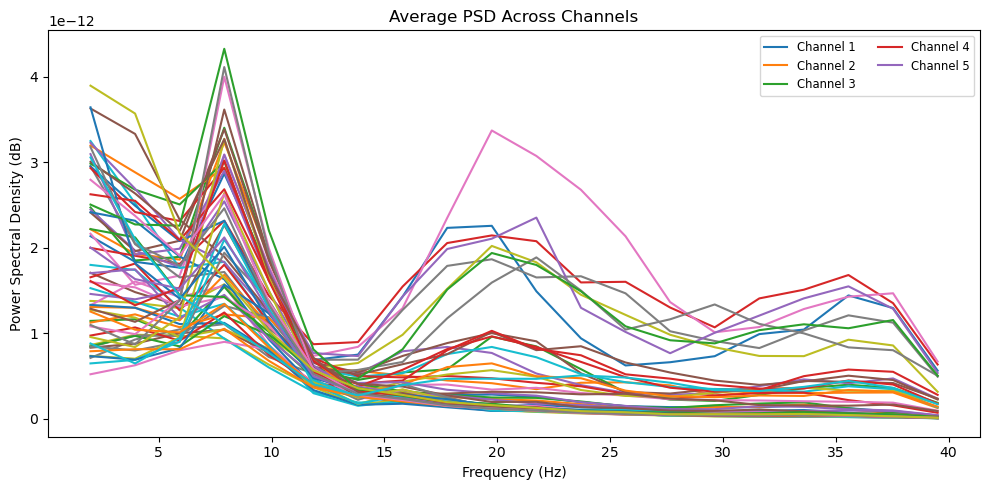

In [29]:
# --- Visualize PSD ---
# Average PSD across epochs
avg_psd = psd.mean(axis=0)  # Shape: (n_channels, n_freqs)

plt.figure(figsize=(10, 5))
for ch_idx, ch_psd in enumerate(avg_psd):
    plt.plot(freqs, ch_psd, label=f"Channel {ch_idx+1}" if ch_idx < 5 else "")  # Plot up to 5 labels
plt.title("Average PSD Across Channels")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.legend(loc="upper right", ncol=2, fontsize="small")
plt.tight_layout()
plt.show()

In [28]:
# Average PSD across epochs
avg_psd = psd.mean(axis=0)  # Shape: (n_channels, n_freqs)

# Define frequency bands
bands = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 40),
}

# Initialize an empty DataFrame
band_psd_df = pd.DataFrame(index=epochs.ch_names)

# Calculate mean PSD for each band and add as columns
for band, (fmin, fmax) in bands.items():
    band_indices = np.where((freqs >= fmin) & (freqs < fmax))[0]  # Indices of frequencies in this band
    band_psd_df[band] = avg_psd[:, band_indices].mean(axis=1)  # Average PSD across band frequencies

# Rename index to "Electrode"
band_psd_df.index.name = "Electrode"

print("Frequency Band PSD DataFrame:")
band_psd_df.head()


Frequency Band PSD DataFrame:


,Delta,Theta,Alpha,Beta,Gamma
Electrode,,,,,
EEG 001,1.985120e-12,2.316592e-12,1.207983e-12,1.234450e-12,1.066032e-12
EEG 002,2.071795e-12,2.547383e-12,1.242545e-12,4.201800e-13,2.703679e-13
EEG 003,2.160396e-12,2.648098e-12,1.235514e-12,5.218372e-13,3.158211e-13
EEG 004,1.951658e-12,2.063050e-12,1.154538e-12,1.586629e-12,1.316319e-12
EEG 005,2.205994e-12,2.158086e-12,1.035653e-12,5.248749e-13,3.920029e-13


In [61]:
band_psd_df.shape

(60, 5)

In [66]:
# Before coherence calculation, print the number of electrodes
n_electrodes = len(epochs.ch_names)  # The number of EEG channels in the dataset
print(f"Number of electrodes: {n_electrodes}")


Number of electrodes: 60


### **Compute Coherence**

In [94]:
# Print the number of electrodes being used
n_electrodes = len(epochs.ch_names)  # The number of EEG channels in the dataset
print(f"Number of electrodes: {n_electrodes}")

# Coherence Calculation
sfreq = epochs.info['sfreq']  # Sampling frequency

# Compute coherence using spectral_connectivity_epochs
coh = spectral_connectivity_epochs(epochs, method='coh', sfreq=sfreq,
                                   fmin=1, fmax=40, faverage=False, verbose=False)

# Print the shape of the coherence data
print(f"Coherence shape: {coh.get_data().shape}")  # Shape: (n_pairs, n_freqs)


Number of electrodes: 60


C:\Users\lacom\AppData\Local\Temp\ipykernel_6232\3314126996.py:9: RuntimeWarning: fmin=1.000 Hz corresponds to 0.506 < 5 cycles based on the epoch length 0.506 sec, need at least 5.000 sec epochs or fmin=9.879. Spectrum estimate will be unreliable.
  coh = spectral_connectivity_epochs(epochs, method='coh', sfreq=sfreq,


Coherence shape: (3600, 20)


### **Phase Locking Value (PLV)**

In [95]:
# --- Phase Locking Value (PLV) ---
plv = spectral_connectivity_epochs(epochs, method='plv', sfreq=sfreq,
                                   fmin=8, fmax=13, faverage=True, verbose=False)
print(f"PLV shape: {plv.get_data().shape}")  # Shape: (n_nodes, n_nodes, n_freqs)

C:\Users\lacom\AppData\Local\Temp\ipykernel_6232\4111823096.py:2: RuntimeWarning: fmin=8.000 Hz corresponds to 4.049 < 5 cycles based on the epoch length 0.506 sec, need at least 0.625 sec epochs or fmin=9.879. Spectrum estimate will be unreliable.
  plv = spectral_connectivity_epochs(epochs, method='plv', sfreq=sfreq,


PLV shape: (3600, 1)


### **Phase Amplitude Coupling (PAC)**

In [96]:
# Average data across epochs (n_channels, n_times)
data_mean = data.mean(axis=0)

# Initialize PAC object with normalization and surrogate testing
pac = Pac(idpac=(1, 2, 4), f_pha=(4, 8), f_amp=(30, 90))  # Theta phase and gamma amplitude

# Compute PAC
pac_values = pac.filterfit(sfreq, data_mean)
print(f"PAC shape: {pac_values.shape}")  # Shape: (n_channels, f_amp, f_pha)


Phase Amplitude Coupling object defined
    extract phases (n_pha=1) and amplitudes (n_amps=1)
    true PAC estimation using Mean Vector Length (MVL, Canolty et al. 2006)
    compute surrogates (Swap amplitude time blocks (Bahramisharif et al. 2013), 200 permutations, random_state=5268)
    infer p-values at (p=0.05, mcp=maxstat)
    normalize true PAC estimation by surrogates (Substract the mean and divide by the deviation of the surrogates)


PAC shape: (1, 1, 60)


In [98]:
# PAC values (average across frequencies if needed)
pac_avg = pac_values.mean(axis=(0, 1))  # Average across freq pairs (if multiple)
pac_df = pd.DataFrame({
    "Electrode": epochs.ch_names,
    "PAC": pac_avg
})

print("PAC DataFrame:")
pac_df.head()


PAC DataFrame:


,Electrode,PAC
0,EEG 001,-0.938713
1,EEG 002,0.586499
2,EEG 003,0.437537
3,EEG 004,1.224508
4,EEG 005,1.585490
